In [1]:
import sys
import cv2
import time
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import numpy as np
import pandas as pd
import pickle
import random
import copy

import os
import shutil
from PIL import Image, ImageDraw

import torch
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor, normalize
from torchvision import transforms

from utils import *
from naturaldesign.naturaldesign import NaturalDesign
sys.path.append("..")

In [2]:
test_imagedir = "../datasets/naturaldesign/naturaldesign/"
context_size, target_size = (512, 512), (32, 32)
dataset = NaturalDesign(test_imagedir, context_size, target_size)

In [3]:
# define IVSN model
class IVSN_sti(nn.Module):
  def __init__(self, model):
      super(IVSN_sti, self).__init__()
      self.features = nn.Sequential(*list(model.children())[0][:30])
      for param in self.features.parameters():
        param.requires_grad_ = False

  def forward(self, x):
      x = self.features(x)
      return x

class IVSN_tg(nn.Module):
  def __init__(self, model):
      super(IVSN_tg, self).__init__()
      self.features = nn.Sequential(*list(model.children())[0][:30])
    #   self.pool_layer = nn.AdaptiveMaxPool2d((1, 1))
      for param in self.features.parameters():
        param.requires_grad_ = False

  def forward(self, x):
      x = self.features(x)
    #   x = self.pool_layer(x)
      return x

from torch.nn.modules.conv import Conv2d
ConvSize, NumTemplates, Mylayer = 1, 512, 31
MMconv = Conv2d(NumTemplates, 1, kernel_size = (ConvSize, ConvSize), stride = (1, 1), padding = (1, 1))

In [4]:
model_vgg = models.vgg16(pretrained=True)
model_ivsn_sti = IVSN_sti(model_vgg)
model_ivsn_tg = IVSN_tg(model_vgg)

/Users/nguyentuan/Mirror/python_env/FYP_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nguyentuan/Mirror/python_env/FYP_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
num_pics, size, image_size = len(dataset), 200, (1024, 1280)
IVSN_res = list()
IVSN_attention_map, scanpath = {}, {}

model_ivsn_sti.eval()
model_ivsn_tg.eval()
with torch.no_grad():
    for id in trange(1, num_pics):
        context_images, target_images, bbox = dataset[id]

        # get attention map from IVSN model
        # context_images = transforms.Resize(image_size)(context_images)
        context_ivsn = context_images.unsqueeze(0)
        target_ivsn = target_images.unsqueeze(0)
        cont_output_ivsn = model_ivsn_sti(context_ivsn)
        tg_output_ivsn = model_ivsn_tg(target_ivsn)
        MMconv.weight = torch.nn.Parameter(tg_output_ivsn)
        attention_IVSN = MMconv.forward(cont_output_ivsn)
        attention_IVSN = attention_IVSN.detach().squeeze(0)

        tg_loc = bbox_cordinates(bbox, image_size[1], image_size[0])

        # process IVSN attention map
        mask_IVSN = transforms.Resize(image_size)(attention_IVSN)
        mask_IVSN = torch.divide(mask_IVSN, mask_IVSN.max())

        IVSN_attention_map[id] = copy.deepcopy(mask_IVSN)

        IVSN_num, path = searchProcesswithPath(tg_loc, mask_IVSN, image_size, size)
        scanpath[id] = path
        IVSN_res.append(IVSN_num)
        print('IVSN_' + str(id) + ': ' + str(IVSN_num), end = '\t')

  0%|▍                                                                                            | 1/240 [00:00<01:26,  2.76it/s]

IVSN_1: 3	

  1%|▊                                                                                            | 2/240 [00:00<01:18,  3.03it/s]

IVSN_2: 6	

  1%|█▏                                                                                           | 3/240 [00:00<01:17,  3.05it/s]

...

IVSN_238: 4	

100%|██████████████████████████████████████████████████████████████████████████████████████████▌| 239/240 [01:14<00:00,  3.14it/s]

IVSN_239: 4	

100%|███████████████████████████████████████████████████████████████████████████████████████████| 240/240 [01:14<00:00,  3.20it/s]

IVSN_240: 4	

In [6]:
IVSN_naturaldesign_res = {}
IVSN_naturaldesign_res['scanpath'] = scanpath
IVSN_naturaldesign_res['attention_map'] = IVSN_attention_map

In [7]:
with open("../results/NaturalDesign/[Fig5]NaturalDesign_IVSN_res.pkl", "wb") as tf:
    pickle.dump(IVSN_naturaldesign_res, tf)

In [8]:
IVSN_accu = model_performance(IVSN_res, len(IVSN_res))
IVSN_accu[:10]

[0,
 np.float64(0.1125),
 np.float64(0.24583333333333332),
 np.float64(0.35833333333333334),
 np.float64(0.44583333333333336),
 np.float64(0.5041666666666667),
 np.float64(0.5791666666666667),
 np.float64(0.6375),
 np.float64(0.6916666666666667),
 np.float64(0.7166666666666667)]

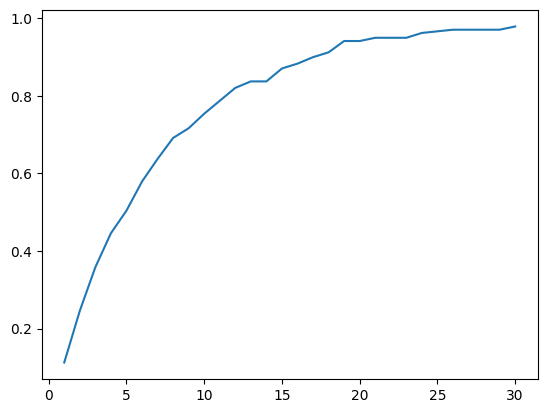

In [9]:
plt.plot(range(1,31), IVSN_accu[1:31])

In [10]:
with open("../results/NaturalDesign/naturaldesign_IVSN_accu_performance.pkl", "wb") as tf:
    pickle.dump(IVSN_accu, tf)